### This notebook computes "VCA1.Index of farmers recieving training and tehnical assistance" indicator for the 27 basins of IKI Project

Spanish: Índice de productores agropecuarios con capacitación y asistencia técnica

**Created:** 10/10/2025 by Serena Gilson (sgilson@rti.org)  
**Project #:** 0219481  
**Last modified:**
**Status:** Complete and loaded in SQLite. 
**QA Status:** reviewed by  
**Original Script Stored at:** Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\Vulnerabilidad
 
**Inputs:**   Shapefile of COMIDs and districts, INEI report downloaded from http://censos1.inei.gob.pe/Cenagro/redatam/# 
 
**Assumptions:** Using weighted method to assign values to each COMID.
 
**N/A Handling** 

**Calculation Summary** 

**Future work:** 
 
**Notes:** 

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import sqlite3
import matplotlib.pyplot as plt

In [2]:
#SETTINGS 

#user = 'jmayo'
#user= 'cpickering'
user = 'sgilson'
ScnID= 1 #Scenario ID -- 1: Baseline, 1981-2005, 2: Future, 2030, 3: Future: 2050
IndID= 501 #Indicator ID ((Exposure = 2 + 0X where X is the Exposure Indicator number, Peligro= 1 +0x, VSB= 3 +0x, VSS= 4 +0x, VCA= 5 +0x)
db_path = fr'C:\Users\{user}\Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\BD_RiesgoClimatico_IKI.db'

In [3]:
#INPUTS

#Define District_within_COMID fractions csv - this allows for a weighted method to be used for assigning district level data to subbasins
district_area_within_COMID= pd.read_csv(f'C:/Users/{user}/Research Triangle Institute/IKI Peru Project - General/Interno/AI2a_Metodologia/Indicadores/COMID_District_Fractions.csv')

subbasins_shapefile = f'C:/Users/{user}/Research Triangle Institute/IKI Peru Project - General/Interno/AI2b_Modelacion/Grupos_Modelacion/GIS_WaterALLOC_General/Peru_AHD_with_districts.shp'
subbasins_gdf = gpd.read_file(subbasins_shapefile).to_crs('EPSG:32718')

#read in excel  (save xls as xlsx as needed before reading in)
productores= pd.read_excel(f'C:/Users/{user}/Research Triangle Institute/IKI Peru Project - General/Interno/AI2a_Metodologia/Indicadores/Vulnerabilidad/INEI_reporte_VCA1.xlsx')

top_row_name= 'Temas de la capacitación'

In [4]:
#WEIGHTED METHOD FUNCTION 
def calculate_proportionate_values(district_fractions_df, value_df, column_name, comid_list):
    """
    Calculate proportionate values for each COMID based on district area fractions
    
    Parameters:
    - district_fractions_df: DataFrame with COMID, DISTRICT, district_area_within_COMID_fraction
    - value_df: DataFrame with IDDIST and indicator values
    - column_name: Name of the column containing the indicator values
    - comid_list: List of COMIDs to process
    
    Returns:
    - DataFrame with COMID and proportionate_indicator_value
    """
    # Ensure IDDIST and DISTRICT columns are in the same format
    value_df = value_df.copy()
    district_fractions_df = district_fractions_df.copy()
    
    value_df['IDDIST'] = value_df['IDDIST'].astype(str).str.strip()
    district_fractions_df['DISTRICT'] = district_fractions_df['DISTRICT'].astype(str).str.strip()
    
    results = []
    
    for comid in comid_list:
        # Get all districts within this COMID
        districts_in_comid = district_fractions_df[district_fractions_df['COMID'] == comid]
        
        total_proportionate_value = 0
        
        for _, row in districts_in_comid.iterrows():
            district_id = row['DISTRICT']
            fraction = row['district_area_within_COMID_fraction']
            # Get the indicator value for this district
            ind_value = value_df[value_df['IDDIST'] == district_id][column_name].values

            if len(ind_value) > 0:
                # Multiply district value by the fraction of area within COMID
                proportionate_value = ind_value[0] * fraction
                total_proportionate_value += proportionate_value
        
        results.append({
            'COMID': comid,
            'proportionate_indicator_value': total_proportionate_value
        })
    
    return pd.DataFrame(results)

In [5]:
#FORMATTING THE DATAFRAME

#remove empty rows 
productores = productores.dropna(axis=0, how='all')  # Drop rows that are completely NaN
#remove unnamed: 2 and and unnamed: 3 columns
productores = productores.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], errors='ignore')
#Keep only rows with 'Total' or 'AREA' in 'Temas de la capacitación' column
productores = productores[productores[top_row_name].str.contains('Total|AREA', case=False, na=False)]

#extract the district name from the dataframe and make a new column with just the district name
productores['District']= productores['Unnamed: 1'].str.split('Dist. ', expand=True)[1].str.strip()

indices_to_drop = []
# Iterate through the rows to check for AREA rows and their corresponding Total rows
for i in range(len(productores) - 1):  # Stop at the second-to-last row to avoid index errors
    if 'AREA' in str(productores.iloc[i][top_row_name]).upper():  # Check if the current row is an AREA row
        next_row = productores.iloc[i + 1]
        if 'TOTAL' in str(next_row[top_row_name]).upper():  # Check if the next row is a Total row
            # Assign the value from the next row to the "Total_Dist" column of the current row
            productores.at[productores.index[i], 'Total_Dist'] = next_row['Unnamed: 1']
            # Mark the Total row for dropping
            indices_to_drop.append(productores.index[i + 1])
# Drop all marked indices at once
productores.drop(index=indices_to_drop, inplace=True)

# Reset the index after dropping rows
productores.reset_index(drop=True, inplace=True)

# Convert Total_Dist to numeric, coercing errors to NaN, then fill NaN with 0 for summing
productores['Total_Dist'] = pd.to_numeric(productores['Total_Dist'], errors='coerce').fillna(0)

#remove all rows from Temas that are NA
productores = productores.dropna(subset=[top_row_name])
#remove all rows from district that are NA
productores = productores.dropna(subset=['District'])

#Create column for District_ID by extracting the number after the # sign in the column Temas de la capacitación
productores['District_ID'] = productores[top_row_name].str.extract(r'(\d+)').astype(int)

# Rename District_ID to IDDIST for consistency with weighted method function
productores = productores.rename(columns={'District_ID': 'IDDIST'})

# Get unique COMIDs from subbasins_gdf
unique_comids = subbasins_gdf['COMID'].unique()

# Calculate proportionate values using weighted method
proportionate_df = calculate_proportionate_values(
    district_area_within_COMID, 
    productores, 
    'Total_Dist',
    unique_comids
)

# Merge back to subbasins_gdf
subbasins_gdf = subbasins_gdf.merge(
    proportionate_df, 
    on='COMID', 
    how='left'
)

# Rename column and round to nearest whole number
subbasins_gdf = subbasins_gdf.rename(columns={'proportionate_indicator_value': 'Total_Productores'})
subbasins_gdf['Total_Productores'] = subbasins_gdf['Total_Productores'].fillna(0).round(0)

# Display results
print("Sample of proportionate productores values:")
print(subbasins_gdf[['COMID', 'Total_Productores']].head(10))
print(f"\nTotal COMIDs: {len(subbasins_gdf)}")
print(f"COMIDs with productores data (>0): {(subbasins_gdf['Total_Productores'] > 0).sum()}")
print(f"COMIDs without productores data (=0): {(subbasins_gdf['Total_Productores'] == 0).sum()}")

Sample of proportionate productores values:
       COMID  Total_Productores
0  311153600               34.0
1  310832400              187.0
2  310825700               32.0
3  310282400               52.0
4  308754600                7.0
5  307736500               12.0
6  307078200                4.0
7  307183500               14.0
8  306538400               51.0
9  306599700              683.0

Total COMIDs: 3655
COMIDs with productores data (>0): 3118
COMIDs without productores data (=0): 537


C:\Users\sgilson\AppData\Local\Temp\ipykernel_24436\46449434.py:19: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()
C:\Users\sgilson\AppData\Local\Temp\ipykernel_24436\46449434.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


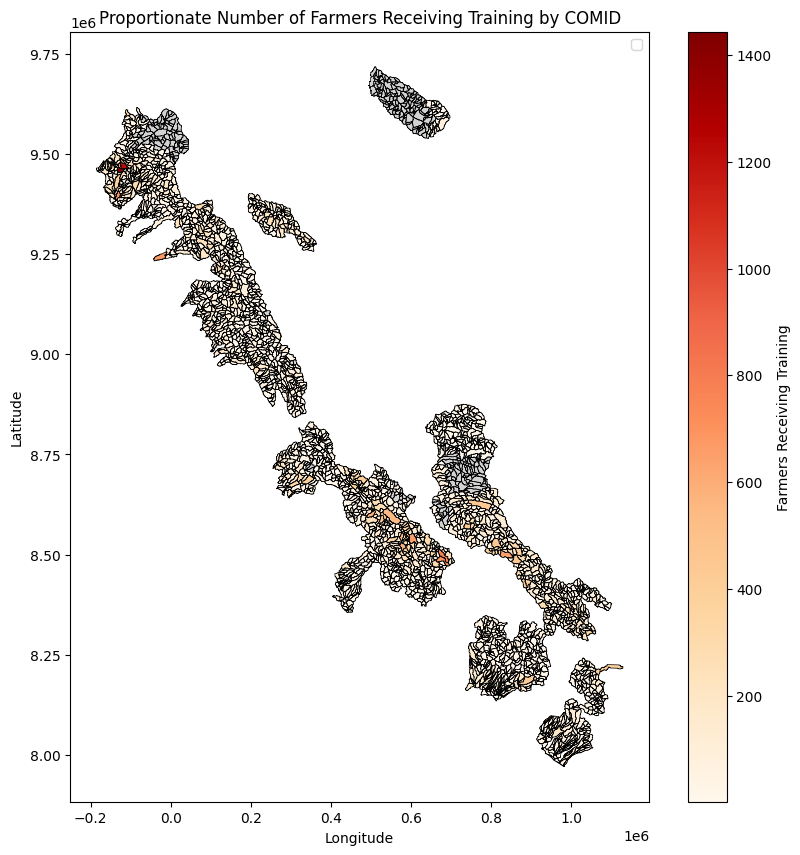

In [6]:
#VISUALIZE 
fig, ax = plt.subplots(figsize=(10, 10))

# Separate zero and non-zero values
zero_values = subbasins_gdf[subbasins_gdf['Total_Productores'] == 0]
nonzero_values = subbasins_gdf[subbasins_gdf['Total_Productores'] > 0]

# Plot zero values in grey
zero_values.plot(ax=ax, color='lightgrey', edgecolor='black', linewidth=0.5, label='No Data (0)')

# Plot non-zero values with color ramp
nonzero_values.plot(column='Total_Productores', ax=ax, cmap='OrRd', 
                    legend=True, edgecolor='black', linewidth=0.5,
                    legend_kwds={'label': 'Farmers Receiving Training'})

plt.title('Proportionate Number of Farmers Receiving Training by COMID')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.show()

SQLITE INSERT 

In [8]:
#Update relevant dataframe and value column from the calculations above for the specific indicator
insert_data= subbasins_gdf #COMID and Total_Productores
value_column= 'Total_Productores' #Column with the calculated indicator values

In [9]:
# Connect to your SQLite database
conn = sqlite3.connect(db_path)
cursor = conn.cursor()

# Fixed IndID and ScnID (update above)

#For now I am commenting out the looping of scenarios as I imagine we might run just baseline scenarios for now.
# Define the mapping between scenario and DataFrame column
# scenario_columns = {
#     1: 'ACTUAL ANUAL',
#     2: '2030 ANUAL',
#     3: '2050 ANUAL'
# }

# Prepare list of rows to insert
rows_to_insert = []

#for scn_id, column_name in scenario_columns.items():
for _, row in insert_data.iterrows():
    comid = row['COMID']
    value = row[value_column]
    #normalized_value = None  # or compute something like: value / max_value #took out normalized value from the table for now
    rows_to_insert.append((ScnID, IndID, comid, value))

# Insert data into IndValues_Dyn
insert_query = """
INSERT OR REPLACE INTO IndValues_Dyn (ScnID, IndID, COMID, Value)
VALUES (?, ?, ?, ?);
"""


In [11]:
rows_to_insert

[(1, 501, 311153600, 34.0),
 (1, 501, 310832400, 187.0),
 (1, 501, 310825700, 32.0),
 (1, 501, 310282400, 52.0),
 (1, 501, 308754600, 7.0),
 (1, 501, 307736500, 12.0),
 (1, 501, 307078200, 4.0),
 (1, 501, 307183500, 14.0),
 (1, 501, 306538400, 51.0),
 (1, 501, 306599700, 683.0),
 (1, 501, 306319300, 90.0),
 (1, 501, 306030000, 10.0),
 (1, 501, 305746400, 18.0),
 (1, 501, 311953100, 15.0),
 (1, 501, 304273900, 0.0),
 (1, 501, 304281100, 0.0),
 (1, 501, 304281200, 0.0),
 (1, 501, 304379300, 0.0),
 (1, 501, 304274000, 0.0),
 (1, 501, 304313700, 0.0),
 (1, 501, 304306400, 0.0),
 (1, 501, 304327700, 0.0),
 (1, 501, 304313800, 0.0),
 (1, 501, 304306300, 0.0),
 (1, 501, 304321600, 0.0),
 (1, 501, 304321700, 0.0),
 (1, 501, 304339400, 0.0),
 (1, 501, 304335700, 0.0),
 (1, 501, 304343200, 0.0),
 (1, 501, 304343100, 0.0),
 (1, 501, 304335800, 0.0),
 (1, 501, 304343000, 0.0),
 (1, 501, 304330900, 0.0),
 (1, 501, 304352700, 0.0),
 (1, 501, 304421200, 0.0),
 (1, 501, 304403000, 0.0),
 (1, 501, 3043

In [10]:
# Check for duplicates in the input dataframe before insert
df_check = pd.DataFrame(rows_to_insert, columns=['ScnID', 'IndID', 'COMID', 'Value'])
duplicates = df_check.duplicated(subset=['ScnID', 'IndID', 'COMID'])
print("Duplicates in rows_to_insert:", df_check[duplicates])

Duplicates in rows_to_insert: Empty DataFrame
Columns: [ScnID, IndID, COMID, Value]
Index: []


In [12]:
#Execute insert to SQLite Database
cursor.executemany(insert_query, rows_to_insert)
conn.commit()
conn.close()